<a href="https://colab.research.google.com/github/sahan-gunatilaka/NRL-Fantasy-data-analysis/blob/main/NRL_Fantasy_data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#importing pandas, sqlite3, and matplotlib
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
# Load the master NRL Fantasy CSV (exported from Google Sheets)
df = pd.read_csv('/content/NRL Fantasy MDB.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Year              158 non-null    int64
 1   Round             158 non-null    int64
 2   Score             158 non-null    int64
 3   Overall Score     158 non-null    int64
 4   Overall Rank      158 non-null    int64
 5   Round rank        158 non-null    int64
 6   Trades made       158 non-null    int64
 7   Trades remaining  158 non-null    int64
dtypes: int64(8)
memory usage: 10.0 KB


# Data cleaning using python

In [5]:
# Drop incomplete rows (e.g. unplayed 2026 rounds with missing scores)
df_clean = df.dropna().copy()

# Rename columns to snake_case to match SQL conventions
df_clean = df_clean.rename(columns={
    'Year': 'season',
    'Round': 'round',
    'Score': 'round_score',
    'Overall Score': 'overall_score',
    'Overall Rank': 'overall_rank',
    'Round rank': 'round_rank',
    'Trades made': 'trades_used',
    'Trades remaining': 'trades_remaining'
})

# Convert numeric columns from float to int (NaNs forced them to float earlier)
cols_to_convert = ['round_score', 'overall_score', 'overall_rank', 'round_rank', 'trades_used', 'trades_remaining']
df_clean[cols_to_convert] = df_clean[cols_to_convert].astype(int)

df_clean.info()
df_clean.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   season            158 non-null    int64
 1   round             158 non-null    int64
 2   round_score       158 non-null    int64
 3   overall_score     158 non-null    int64
 4   overall_rank      158 non-null    int64
 5   round_rank        158 non-null    int64
 6   trades_used       158 non-null    int64
 7   trades_remaining  158 non-null    int64
dtypes: int64(8)
memory usage: 10.0 KB


,season,round,round_score,overall_score,overall_rank,round_rank,trades_used,trades_remaining
0,2021,1,877,877,16741,16741,0,34
1,2021,2,916,1793,14730,16858,1,33
2,2021,3,807,2600,23534,49960,1,32
3,2021,4,963,3563,23054,26658,2,30
4,2021,5,950,4513,23627,28430,2,28
5,2021,6,893,5406,25661,41364,1,27
6,2021,7,783,6189,29455,60721,2,25
7,2021,8,804,6993,31837,57575,2,23
8,2021,9,900,7893,31039,28180,2,21
9,2021,10,941,8834,30559,34750,1,20


In [6]:
# Connect to the SQLite database (creates the file if it doesn't already exist)
conn = sqlite3.connect('nrl_fantasy.db')
cursor = conn.cursor()

In [7]:
# Create the table structure
# Using (season, round) as a composite primary key, since round numbers
# repeat across seasons but the season+round combination is always unique
cursor.execute('''
CREATE TABLE IF NOT EXISTS nrl_fantasy (
    season INTEGER,
    round INTEGER,
    round_score INTEGER,
    overall_score INTEGER,
    overall_rank INTEGER,
    round_rank INTEGER,
    trades_used INTEGER,
    trades_remaining INTEGER,
    PRIMARY KEY (season, round)
)
''')
conn.commit()

In [8]:
# Load cleaned data into the database (replaces the table entirely each run)
df_clean.to_sql('nrl_fantasy', conn, if_exists='replace', index=False)

158

In [9]:
# Verify the table loaded correctly by previewing the first 5 rows
result = pd.read_sql('SELECT * FROM nrl_fantasy LIMIT 5', conn)
result

,season,round,round_score,overall_score,overall_rank,round_rank,trades_used,trades_remaining
0,2021,1,877,877,16741,16741,0,34
1,2021,2,916,1793,14730,16858,1,33
2,2021,3,807,2600,23534,49960,1,32
3,2021,4,963,3563,23054,26658,2,30
4,2021,5,950,4513,23627,28430,2,28


In [10]:
# CConfirm all 158 cleaned rows loaded successfully
pd.read_sql('SELECT COUNT(*) FROM nrl_fantasy', conn)

,COUNT(*)
0,158


# Analysing data using SQL

In [11]:
# Find rounds where I scored over 1000 points — a personal milestone worth tracking
result = pd.read_sql('''
SELECT season, round, round_score
FROM nrl_fantasy
WHERE round_score > 1000
''', conn)
result

,season,round,round_score
0,2021,23,1045
1,2022,21,1043
2,2023,5,1008
3,2023,10,1004
4,2023,15,1082
5,2023,23,1122
6,2023,25,1051
7,2024,18,1087
8,2024,21,1050
9,2024,24,1048


In [12]:
# Find my best (lowest) overall rank achieved in each season
result = pd.read_sql('''
SELECT season, MIN(overall_rank) AS best_rank
FROM nrl_fantasy
GROUP BY season
''', conn)
result

,season,best_rank
0,2021,14730
1,2022,1140
2,2023,3019
3,2024,5121
4,2025,8264
5,2026,3944


In [13]:
# Find rounds where I made no trades at all
result = pd.read_sql('''
SELECT season, round, trades_used
FROM nrl_fantasy
WHERE trades_used = 0
''', conn)
result

,season,round,trades_used
0,2021,1,0
1,2021,12,0
2,2021,14,0
3,2021,22,0
4,2021,23,0
5,2021,24,0
6,2021,25,0
7,2022,1,0
8,2022,2,0
9,2022,6,0


In [14]:
# Rounds where I made 2-4 trades (i.e. active trading rounds)
result = pd.read_sql('''
SELECT season, round, trades_used
FROM nrl_fantasy
WHERE trades_used BETWEEN 2 AND 4
''', conn)
result

,season,round,trades_used
0,2021,4,2
1,2021,5,2
2,2021,7,2
3,2021,8,2
4,2021,9,2
...,...,...,...
86,2026,17,2
87,2026,18,4
88,2026,19,3
89,2026,20,3


In [15]:
# Average round score per season
result = pd.read_sql('''
SELECT season, ROUND(AVG(round_score), 2) AS avg_round_score
FROM nrl_fantasy
GROUP BY season
''', conn)
result

,season,avg_round_score
0,2021,838.72
1,2022,863.92
2,2023,856.74
3,2024,820.22
4,2025,897.04
5,2026,884.48


In [16]:
# Count how many rounds fall into each score tier
result = pd.read_sql('''
SELECT season, round, round_score,
    CASE
        WHEN round_score < 800 THEN 'Low'
        WHEN round_score <= 1000 THEN 'Medium'
        ELSE 'High'
    END AS score_tier
FROM nrl_fantasy
''', conn)
result

,season,round,round_score,score_tier
0,2021,1,877,Medium
1,2021,2,916,Medium
2,2021,3,807,Medium
3,2021,4,963,Medium
4,2021,5,950,Medium
...,...,...,...,...
153,2026,23,782,Low
154,2026,24,752,Low
155,2026,25,985,Medium
156,2026,26,841,Medium


In [17]:
# Count how many rounds fall into each score tier (Low/Medium/High)
result = pd.read_sql('''
SELECT
    CASE
        WHEN round_score < 800 THEN 'Low'
        WHEN round_score <= 1000 THEN 'Medium'
        ELSE 'High'
    END AS score_tier,
    COUNT(*) AS num_rounds
FROM nrl_fantasy
GROUP BY score_tier
''', conn)
result

,score_tier,num_rounds
0,High,20
1,Low,47
2,Medium,91


In [18]:
# Highest score achieved per season
result = pd.read_sql('''
SELECT season, MAX(round_score) AS highest_score
FROM nrl_fantasy
GROUP BY season
''', conn)
result

,season,highest_score
0,2021,1045
1,2022,1043
2,2023,1122
3,2024,1087
4,2025,1110
5,2026,1153


# Visual analysis

In [19]:
# Pull 2022 season data for visualization (best-ranked season)
season_2022 = pd.read_sql('''
SELECT round, round_score, overall_rank, round_rank
FROM nrl_fantasy
WHERE season = 2022
''', conn)

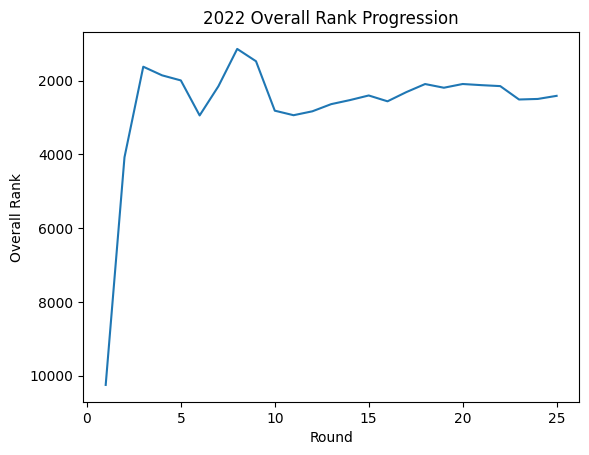

In [20]:
# Plot 2022 overall rank progression
# Y-axis is inverted since a lower rank number is better —
# this makes an improving rank appear as an upward line, matching the score chart's "up = good" reading
plt.plot(season_2022['round'], season_2022['overall_rank'])
plt.xlabel('Round')
plt.ylabel('Overall Rank')
plt.title('2022 Overall Rank Progression')
plt.gca().invert_yaxis()
plt.show()

In [21]:
# Query average round score per season, for the bar chart below
season_averages = pd.read_sql('''
SELECT season, AVG(round_score) AS avg_round_score
FROM nrl_fantasy
GROUP BY season
''', conn)


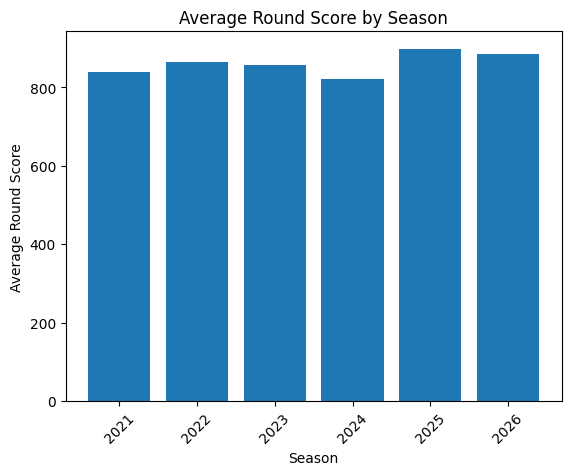

In [22]:
# Bar chart comparing average round score across all six seasons
plt.bar(season_averages['season'], season_averages['avg_round_score'])
plt.xlabel('Season')
plt.ylabel('Average Round Score')
plt.title('Average Round Score by Season')
plt.xticks(rotation=45)
plt.show()

In [23]:
# Get the overall rank I finished each season on (i.e. the rank at the last round played)
# Uses a subquery to find each season's max round, then pulls the rank for that specific row
final_rank_by_season = pd.read_sql('''
SELECT season, round, overall_rank
FROM nrl_fantasy
WHERE (season, round) IN (
    SELECT season, MAX(round)
    FROM nrl_fantasy
    GROUP BY season
)
ORDER BY season
''', conn)

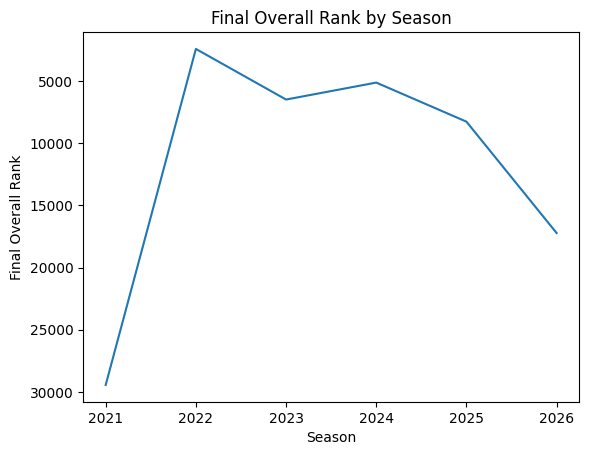

In [24]:
# Line chart of final overall rank by season
# Y-axis inverted since lower rank is better — an upward line means an improving finish
plt.plot(final_rank_by_season['season'], final_rank_by_season['overall_rank'])
plt.xlabel('Season')
plt.ylabel('Final Overall Rank')
plt.title('Final Overall Rank by Season')
plt.gca().invert_yaxis()
plt.show()